# Demo: Lysozyme Pipeline Quick Run
This notebook runs the pipeline on three small demo pairs (1 Yen c2/c1 pair, 2 Karen RFP/DAPI pairs) copied into `demo/images`.
- **Single image run**: Yen dataset pair (`c2`/`c1`).
- **Batch Dask-style run**: Karen dataset pairs (`_RFP`/`_DAPI`).
Outputs are written under `results/demo_yen_single` and `results/demo_karen_batch`.

In [1]:
# Setup paths and imports
from pathlib import Path
import sys

# Notebook lives in <repo>/demo; repo root is its parent
REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from src.lysozyme_pipelines import DatasetConfig, ScaleLookup, run_dask_pipeline

RESULTS_ROOT = REPO_ROOT / "demo" / "outputs"
DEMO_ROOT = REPO_ROOT / "demo" / "images"
YEN_DEMO = DEMO_ROOT / "yen_lab"
KAREN_DEMO = DEMO_ROOT / "karen"
YEN_DEMO, KAREN_DEMO, RESULTS_ROOT

(PosixPath('/home/ash/documents/code/lysozyme/demo/images/yen_lab'),
 PosixPath('/home/ash/documents/code/lysozyme/demo/images/karen'),
 PosixPath('/home/ash/documents/code/lysozyme/demo/outputs'))

In [2]:
# Quick sanity check of available demo images
print('Yen demo files:', sorted(p.name for p in YEN_DEMO.glob('*.tif')))
print('Karen demo files:', sorted(p.name for p in KAREN_DEMO.glob('*.tif')))

Yen demo files: ['Jej-1c1.tif', 'Jej-1c2.tif']
Karen demo files: ['G2EB - 2_DAPI.tif', 'G2EB - 2_RFP.tif', 'G5ER - 2_DAPI.tif', 'G5ER - 2_RFP.tif']


## Single-image run (Yen dataset)
Runs only the first Yen pair using threaded execution. Adjust `max_subjects` or `use_cluster` if you add more demo files.

In [ ]:
yen_demo_cfg = DatasetConfig(
    image_base_dir=YEN_DEMO,
    exp_name="demo_yen_single",
    blob_size_um=18.0,
    max_regions_per_image=5,
    scoring_weights={
        "circularity": 0.25,
        "area": 0.25,
        "line_fit": 0.35,
        "red_intensity": 0.85,
        "com_consistency": 0.50,
    },
    scale_lookup=ScaleLookup(default_value=0.4476, keys=("40x",), values=(0.2253,)),
    channel_keys=("c2", "c1"),
    include_unmatched_combined=False,
    rfp_channel_index=1,
    dapi_channel_index=2,
 )

run_dask_pipeline(
    dataset_cfg=yen_demo_cfg,
    results_root=RESULTS_ROOT,
    use_cluster=False,
    force_respawn_cluster=False,
    n_workers=None,
    threads_per_worker=None,
    save_images=True,
    debug=True,
    max_subjects=1,
    connect_to_existing_cluster=False,
    use_timestamps=False,
    debug_image_capture=True,
    debug_image_whitelist=None,
    debug_subject_limit=None,
    debug_subject_whitelist=None,
 )

DASK-BASED LYSOZYME CRYPT DETECTION PIPELINE
[x] Results will be saved to: /home/ash/documents/code/lysozyme/demo/outputs/results/demo_yen_single

[x] Debug intermediate capture enabled for 47 stages.
    Output directory: /home/ash/documents/code/lysozyme/demo/outputs/results/demo_yen_single/debug_intermediates

[x] Debug capture enabled for all subjects (<=5).
[x] Created Dask bag with:
	 0 subjects from combined channels
	 and 1 subjects from seperate channels.

[x] Executing Dask bag with 1 subjects...



### View Yen overlay in-notebook

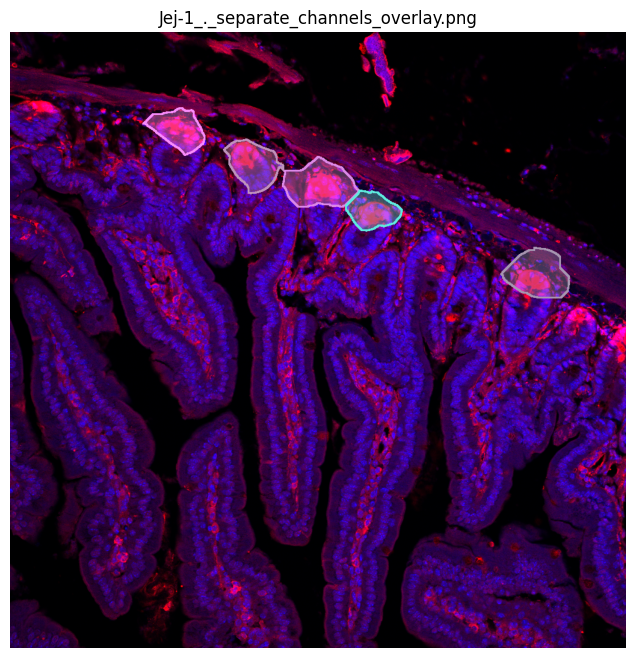

In [ ]:
# Display requested Yen overlay in-line (no extra outputs)
import matplotlib.pyplot as plt
from pathlib import Path
target = REPO_ROOT / "results" / "demo_yen_single" / "renderings" / "Jej-1_._separate_channels_overlay.png"
if not target.exists():
    print("Requested overlay not found; run the Yen pipeline cell first.")
else:
    img = plt.imread(target)
    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(target.name)
    plt.show()


# yen_overlay_dir = REPO_ROOT / "results" / "demo_yen_single" / "renderings"
# yen_overlays = sorted(yen_overlay_dir.glob("*.png"))
# if not yen_overlays:
#     print("No overlays found yet. Run the Yen cell above first.")
# else:
#     img = plt.imread(yen_overlays[0])
#     plt.figure(figsize=(8,8))
#     plt.imshow(img)
#     plt.axis('off')
#     plt.title(yen_overlays[0].name)
#     plt.show()



## Batch run (Dask-style, Karen dataset)
Processes both Karen pairs. Set `use_cluster=True` to spin up a local Dask cluster; keep `False` for threaded execution.

In [ ]:
karen_demo_cfg = DatasetConfig(
    image_base_dir=KAREN_DEMO,
    exp_name="demo_karen_batch",
    blob_size_um=50.0 * 0.4476,
    max_regions_per_image=5,
    scoring_weights={
        "circularity": 0.15,
        "area": 0.25,
        "line_fit": 0.35,
        "red_intensity": 0.85,
        "com_consistency": 0.050,
    },
    effective_count_scoring_weights={
        "circularity": 0.35,
        "area": 0.15,
        "line_fit": 0.45,
        "red_intensity": 0.25,
    },
    scale_lookup=ScaleLookup(default_value=0.4476, keys=("40x",), values=(0.2253,)),
    channel_keys=("_RFP", "_DAPI"),
    include_unmatched_combined=True,
 )

run_dask_pipeline(
    dataset_cfg=karen_demo_cfg,
    results_root=RESULTS_ROOT,
    use_cluster=False,  # flip to True to use dask.distributed if available
    force_respawn_cluster=False,
    n_workers=None,
    threads_per_worker=None,
    save_images=True,
    debug=False,
    max_subjects=None,
    connect_to_existing_cluster=False,
    use_timestamps=False,
    debug_image_capture=True,
    debug_image_whitelist=None,
    debug_subject_limit=None,
    debug_subject_whitelist=None,
 )

DASK-BASED LYSOZYME CRYPT DETECTION PIPELINE
[x] Results will be saved to: /home/ash/documents/code/lysozyme/results/demo_karen_batch

[x] Compute took 88.37 seconds

[Saving] Writing aggregated CSVs...


### View Karen overlay in-notebook

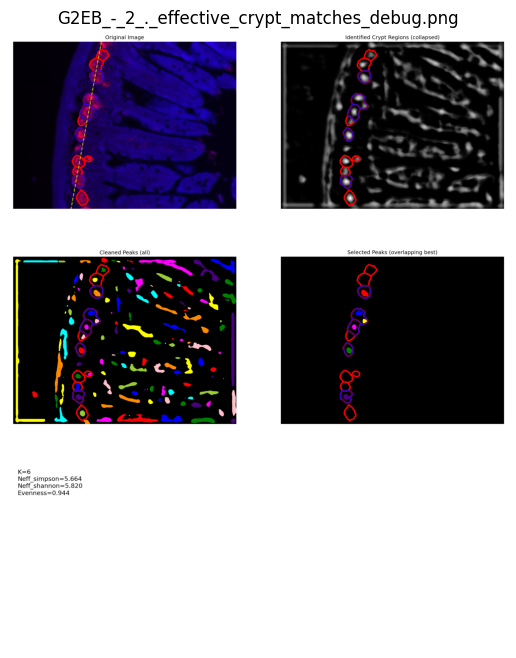

In [ ]:
# Display first Karen overlay in-line
import matplotlib.pyplot as plt
from pathlib import Path
karen_overlay_dir = RESULTS_ROOT / "demo_karen_batch" / "renderings"
karen_overlays = sorted(karen_overlay_dir.glob("*.png"))
if not karen_overlays:
    print("No overlays found yet. Run the Karen cell above first.")
else:
    img = plt.imread(karen_overlays[0])
    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(karen_overlays[0].name)
    plt.show()

## Inspecting outputs
- Yen overlays: `results/demo_yen_single/renderings/`
- Karen overlays: `results/demo_karen_batch/renderings/`
- CSVs: `results/<exp_name>/simple_dask_image_summary*.csv`